In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("marketing_funnel.csv.csv")
df.head()

,Page Views,Session Duration,Bounce Rate,Traffic Source,Time on Page,Previous Visits,Conversion Rate
0,5,11.051381,0.230652,Organic,3.890460,3,1.0
1,4,3.429316,0.391001,Social,8.478174,0,1.0
2,4,1.621052,0.397986,Organic,9.636170,2,1.0
3,5,3.629279,0.180458,Organic,2.071925,3,1.0
4,5,4.235843,0.291541,Paid,1.960654,5,1.0


In [8]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Page Views        2000 non-null   int64  
 1   Session Duration  2000 non-null   float64
 2   Bounce Rate       2000 non-null   float64
 3   Traffic Source    2000 non-null   object 
 4   Time on Page      2000 non-null   float64
 5   Previous Visits   2000 non-null   int64  
 6   Conversion Rate   2000 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 109.5+ KB
None
        Page Views  Session Duration  Bounce Rate  Time on Page  \
count  2000.000000       2000.000000  2000.000000   2000.000000   
mean      4.950500          3.022045     0.284767      4.027439   
std       2.183903          3.104518     0.159781      2.887422   
min       0.000000          0.003613     0.007868      0.068515   
25%       3.000000          0.815828     0.161986      1.935037   


In [9]:
# Assuming Conversion Rate = 1 means converted
df['Converted'] = df['Conversion Rate'].apply(lambda x: 1 if x > 0 else 0)

In [10]:
conversion_rate = df['Converted'].mean() * 100
print("Overall Conversion Rate:", conversion_rate)

Overall Conversion Rate: 100.0


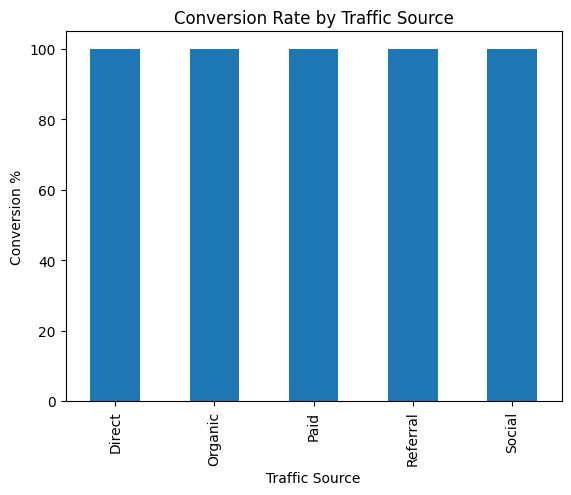

In [11]:
traffic_perf = df.groupby('Traffic Source')['Converted'].mean() * 100

traffic_perf.plot(kind='bar')
plt.title("Conversion Rate by Traffic Source")
plt.ylabel("Conversion %")
plt.show()

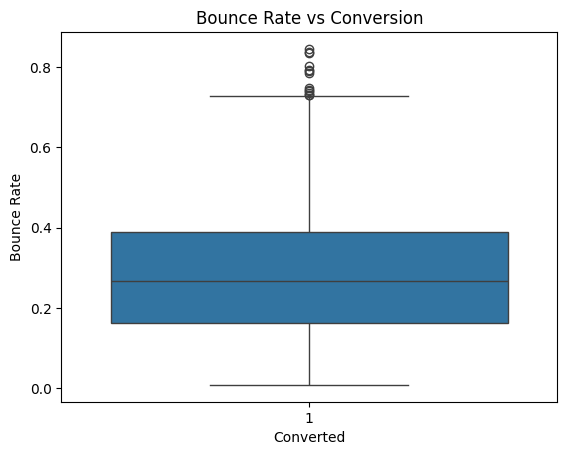

In [12]:
sns.boxplot(data=df, x='Converted', y='Bounce Rate')
plt.title("Bounce Rate vs Conversion")
plt.show()

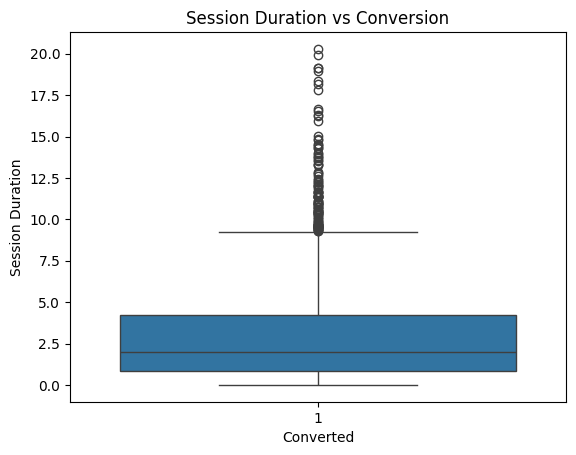

In [13]:
sns.boxplot(data=df, x='Converted', y='Session Duration')
plt.title("Session Duration vs Conversion")
plt.show()

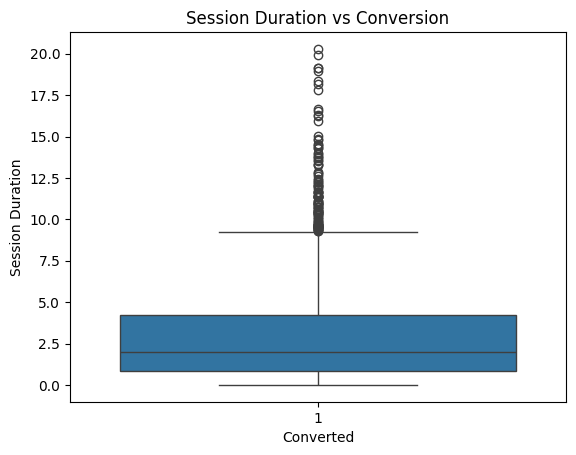

In [14]:
sns.boxplot(data=df, x='Converted', y='Session Duration')
plt.title("Session Duration vs Conversion")
plt.show()

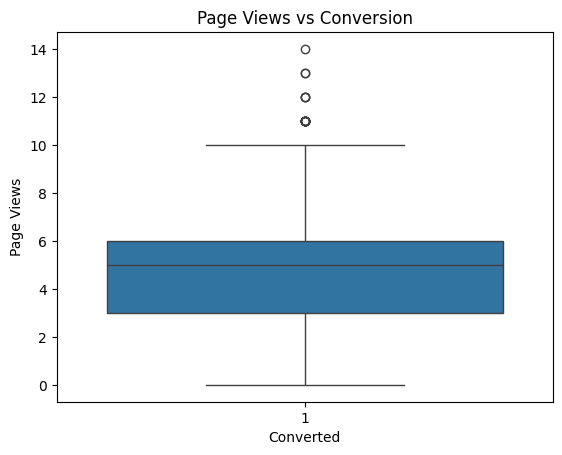

In [15]:
sns.boxplot(data=df, x='Converted', y='Page Views')
plt.title("Page Views vs Conversion")
plt.show()

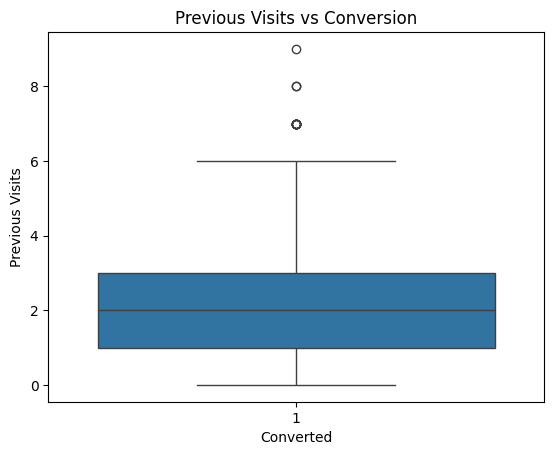

In [16]:
sns.boxplot(data=df, x='Converted', y='Previous Visits')
plt.title("Previous Visits vs Conversion")
plt.show()

Funnel Stage
High Engagement      100.0
Low Engagement       100.0
Medium Engagement    100.0
Name: Converted, dtype: float64


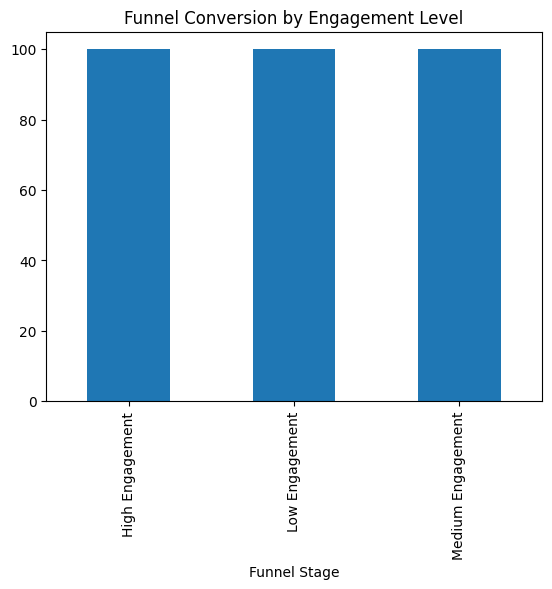

In [18]:
# Define funnel stages based on behavior
conditions = [
    (df['Page Views'] <= 2),
    (df['Page Views'] > 2) & (df['Page Views'] <= 4),
    (df['Page Views'] > 4)
]

stages = ['Low Engagement', 'Medium Engagement', 'High Engagement']

df['Funnel Stage'] = np.select(conditions, stages, default='Not Classified')

funnel = df.groupby('Funnel Stage')['Converted'].mean() * 100
print(funnel)

funnel.plot(kind='bar')
plt.title("Funnel Conversion by Engagement Level")
plt.show()

In [19]:
total_users = len(df)
total_converted = df['Converted'].sum()

print("Total Users:", total_users)
print("Total Converted:", total_converted)

Total Users: 2000
Total Converted: 2000
